Silhouette at k=3: 0.285
ARI vs true labels: 0.897
PC1+PC2 explain: 55.41% of variance


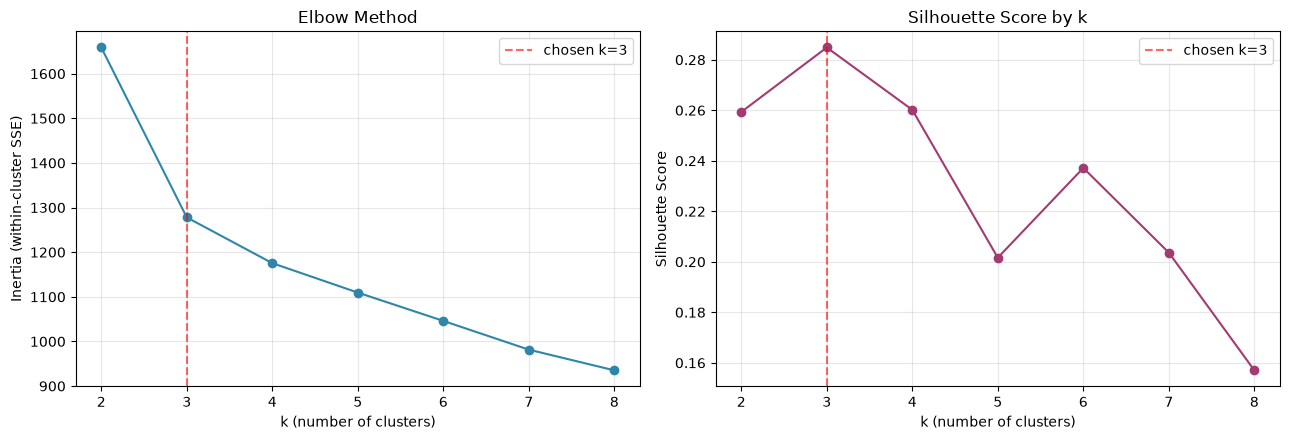

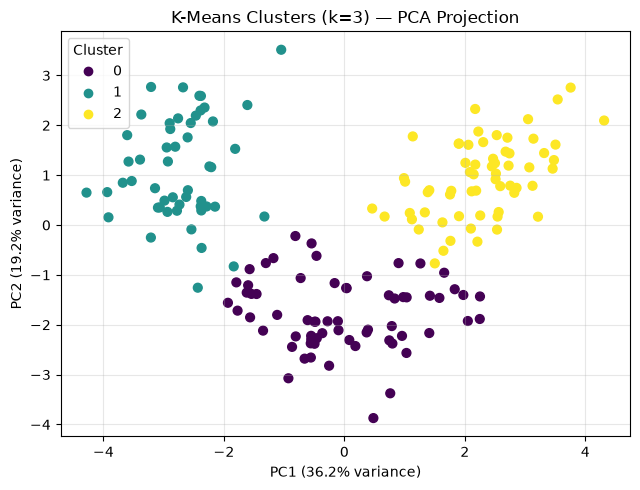

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# ---------------------------------------------------------------
# 1. LOAD DATA
#    Wine dataset: 178 samples, 13 chemical features.
#    y_true = real wine class (0,1,2) — only used to check our
#    clustering at the very end, NOT during training.
# ---------------------------------------------------------------
data = load_wine()
X = data.data          # features (178 x 13)
y_true = data.target   # true labels (178,)

# ---------------------------------------------------------------
# 2. SCALE FEATURES
#    K-Means uses distance, so features must be on the same scale.
#    StandardScaler makes each feature mean=0, std=1.
# ---------------------------------------------------------------
X_scaled = StandardScaler().fit_transform(X)

# ---------------------------------------------------------------
# 3. TRY k = 2..8 and record two scores
#    - inertia  = sum of squared distances to nearest centroid
#                 (lower is tighter, but always drops as k grows)
#    - silhouette = how well-separated clusters are (-1 to 1)
# ---------------------------------------------------------------
ks = list(range(2, 9))
inertias, sil_scores = [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

# ---------------------------------------------------------------
# 4. FINAL MODEL at k=3 (wine has 3 real classes)
#    ARI compares our cluster labels to the true labels:
#      1.0 = perfect match, 0.0 = random.
# ---------------------------------------------------------------
km_final = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_scaled)
labels = km_final.labels_
ari = adjusted_rand_score(y_true, labels)

# ---------------------------------------------------------------
# 5. PCA — just for VISUALIZATION
#    We have 13 features, can't plot 13D. PCA finds the 2 new
#    axes ("principal components") that capture the most variance.
#    - PC1 = direction of biggest spread in the data
#    - PC2 = next biggest, perpendicular to PC1
#    These 2 numbers per sample are enough to draw a 2D picture.
#    (Clustering already happened above — PCA does NOT affect it.)
# ---------------------------------------------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)     # shape (178, 2)
explained = pca.explained_variance_ratio_   # e.g. [0.36, 0.19]

print(f"Silhouette at k=3: {sil_scores[ks.index(3)]:.3f}")
print(f"ARI vs true labels: {ari:.3f}")
print(f"PC1+PC2 explain: {explained.sum():.2%} of variance")

# ---------------------------------------------------------------
# VISUAL 1: How to pick k
#   Left  = elbow plot (look for the "bend")
#   Right = silhouette (higher = better separation)
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(ks, inertias, marker="o", color="#2E86AB")
axes[0].axvline(3, ls="--", color="red", alpha=0.6, label="chosen k=3")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_title("Elbow Method")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ks, sil_scores, marker="o", color="#A23B72")
axes[1].axvline(3, ls="--", color="red", alpha=0.6, label="chosen k=3")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# ---------------------------------------------------------------
# VISUAL 2: Cluster assignments shown in 2D PCA space
#   Each dot = one wine sample, colored by its cluster label.
#   Note: PCA was only used to make this picture — clustering
#   used all 13 scaled features.
# ---------------------------------------------------------------
plt.figure(figsize=(6.5, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis", s=40)
plt.xlabel(f"PC1 ({explained[0]:.1%} variance)")
plt.ylabel(f"PC2 ({explained[1]:.1%} variance)")
plt.title("K-Means Clusters (k=3) — PCA Projection")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [3]:
# See why scaling matters
print("Before scaling — mean & std per feature (first 5):")
print("mean:", np.round(X.mean(axis=0)[:5], 2))
print("std :", np.round(X.std(axis=0)[:5], 2))

print("\nAfter scaling:")
print("mean:", np.round(X_scaled.mean(axis=0)[:5], 2))
print("std :", np.round(X_scaled.std(axis=0)[:5], 2))

Before scaling — mean & std per feature (first 5):
mean: [13.    2.34  2.37 19.49 99.74]
std : [ 0.81  1.11  0.27  3.33 14.24]

After scaling:
mean: [ 0.  0. -0. -0. -0.]
std : [1. 1. 1. 1. 1.]


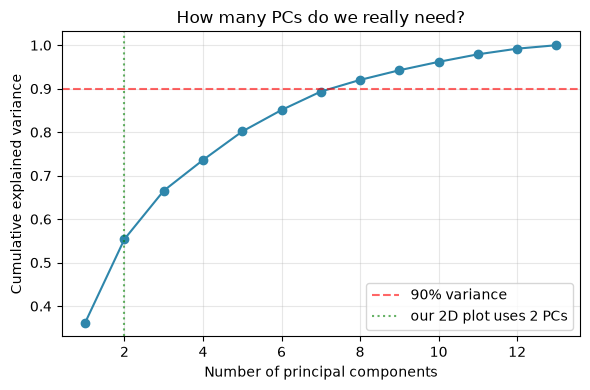

PCs needed for 90% variance: 8


In [4]:
pca_full = PCA().fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o", color="#2E86AB")
plt.axhline(0.9, ls="--", color="red", alpha=0.6, label="90% variance")
plt.axvline(2, ls=":", color="green", alpha=0.6, label="our 2D plot uses 2 PCs")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("How many PCs do we really need?")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("PCs needed for 90% variance:",
      np.argmax(cum_var >= 0.9) + 1)

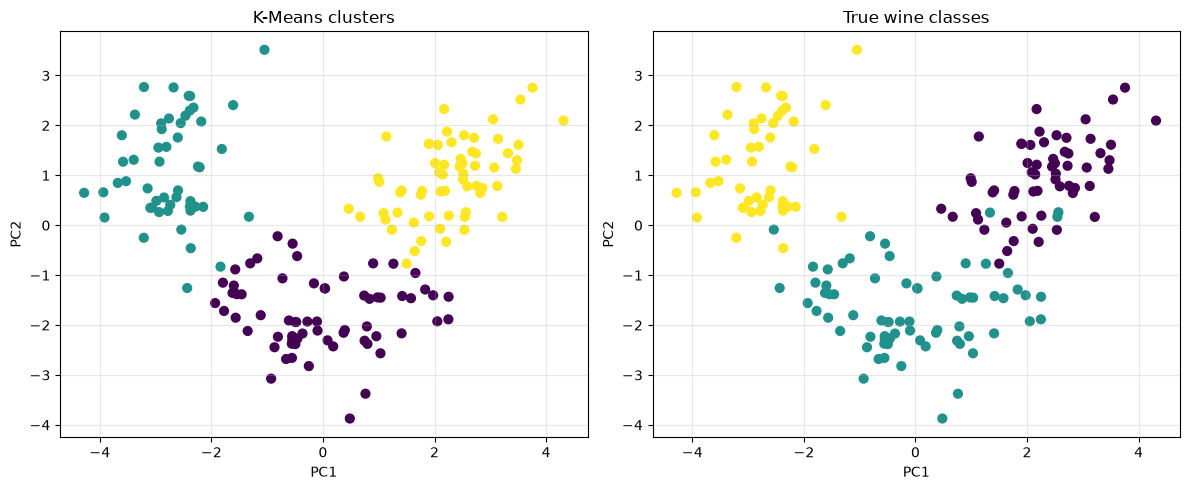

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis", s=40)
axes[0].set_title("K-Means clusters")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap="viridis", s=40)
axes[1].set_title("True wine classes")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")

for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
